First 5 rows:
   student_id  weekly_self_study_hours  attendance_percentage  \
0           1                     18.5                   95.6   
1           2                     14.0                   80.0   
2           3                     19.5                   86.3   
3           4                     25.7                   70.2   
4           5                     13.4                   81.9   

   class_participation  total_score grade  
0                  3.8         97.9     A  
1                  2.5         83.9     B  
2                  5.3        100.0     A  
3                  7.0        100.0     A  
4                  6.9         92.0     A  

Dataset Shape:
(190362, 6)

Column Names:
Index(['student_id', 'weekly_self_study_hours', 'attendance_percentage',
       'class_participation', 'total_score', 'grade'],
      dtype='object')

Grade Distribution:
grade
A    104489
B     49287
C     26808
D      8565
F      1213
Name: count, dtype: int64

Sampled Dataset Shape:
(

/tmp/ipykernel_779/1086757380.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(



Grade Classes:
['A' 'B' 'C' 'D' 'F']

Training Samples: 55822
Testing Samples: 13956

Training Completed!
Number of Epochs Used: 47

MODEL PERFORMANCE
Accuracy: 0.9972771567784465
Accuracy Percentage: 99.73 %

Confusion Matrix:
[[3991    9    0    0    0]
 [   1 3993    6    0    0]
 [   0    1 3987   12    0]
 [   0    0    2 1705    6]
 [   0    0    0    1  242]]

Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00      4000
           B       1.00      1.00      1.00      4000
           C       1.00      1.00      1.00      4000
           D       0.99      1.00      0.99      1713
           F       0.98      1.00      0.99       243

    accuracy                           1.00     13956
   macro avg       0.99      1.00      0.99     13956
weighted avg       1.00      1.00      1.00     13956



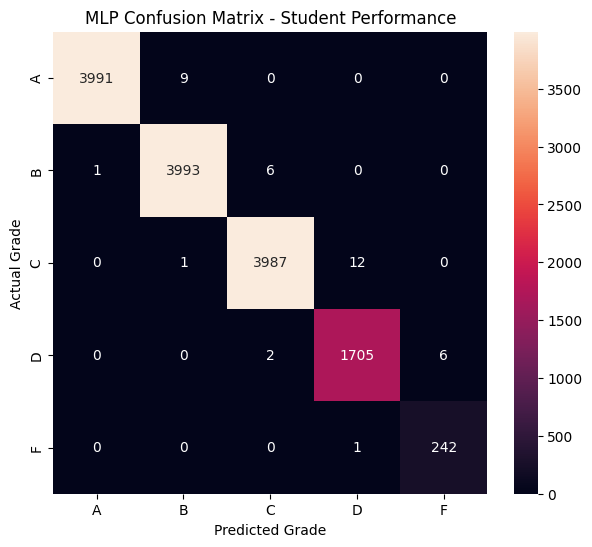

In [ ]:


# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report



# 2. Load Dataset


data = pd.read_csv("student_performance.csv")

print("First 5 rows:")
print(data.head())

print("\nDataset Shape:")
print(data.shape)

print("\nColumn Names:")
print(data.columns)

print("\nGrade Distribution:")
print(data["grade"].value_counts())



# 3. Select Features and Target


X = data[
    [
        "weekly_self_study_hours",
        "attendance_percentage",
        "class_participation",
        "total_score"
    ]
]

y = data["grade"]


# 4. Take a Balanced Sample

sample_data = (
    data.groupby("grade", group_keys=False)
    .apply(
        lambda x: x.sample(
            n=min(len(x), 20000),
            random_state=42
        ),
        include_groups=True
    )
)

print("\nSampled Dataset Shape:")
print(sample_data.shape)

print("\nSampled Grade Distribution:")
print(sample_data["grade"].value_counts())

# 5. Select X and y from Sample


X = sample_data[
    [
        "weekly_self_study_hours",
        "attendance_percentage",
        "class_participation",
        "total_score"
    ]
]

y = sample_data["grade"]



# 6. Encode Grade Labels



label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print("\nGrade Classes:")
print(label_encoder.classes_)


# 7. Split Dataset


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))


# 8. Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

# Use the SAME scaler for testing data

X_test = scaler.transform(X_test)


# 9. Create MLP Model


mlp = MLPClassifier(

    # Two hidden layers
    hidden_layer_sizes=(64, 32),

    # Activation function
    activation="relu",

    # Optimization algorithm
    solver="adam",

    # L2 Regularization
    alpha=0.0001,

    # Early Stopping
    early_stopping=True,

    # 15% of training data used for validation
    validation_fraction=0.15,

    # Stop if validation score does not improve
    # for 10 consecutive epochs
    n_iter_no_change=10,

    # Maximum number of epochs
    max_iter=100,

    # Batch size
    batch_size=256,

    random_state=42
)


# 10. Train MLP


mlp.fit(X_train, y_train)

print("\nTraining Completed!")

print("Number of Epochs Used:", mlp.n_iter_)

# 11. Prediction


y_pred = mlp.predict(X_test)


# 12. Calculate Accuracy


accuracy = accuracy_score(y_test, y_pred)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print("Accuracy:", accuracy)

print("Accuracy Percentage:",
      round(accuracy * 100, 2), "%")



# 13. Confusion Matrix


cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# 14. Classification Report


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)


# 15. Plot Confusion Matrix


plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Grade")
plt.ylabel("Actual Grade")

plt.title("MLP Confusion Matrix - Student Performance")

plt.show()